In [15]:
from pyod.utils.data import generate_data
from pyod.models.ocsvm import OCSVM
from pyod.models.deep_svdd import DeepSVDD
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ex 1

In [7]:
train_size = 300
test_size = 200 
dim = 3
contamination = 0.15

X_train, X_test, y_train, y_test = generate_data(n_train=train_size, n_test=test_size, n_features=dim, contamination=contamination)

In [8]:
ocsvm_model = OCSVM(kernel='linear', contamination=contamination)

ocsvm_model.fit(X_train)
train_preds = ocsvm_model.predict(X_train)
test_preds = ocsvm_model.predict(X_test)

test_balanced_accuracy = balanced_accuracy_score(y_test, test_preds)
test_roc_auc = roc_auc_score(y_test, test_preds) 

print(test_balanced_accuracy)
print(test_roc_auc)

0.95
0.95


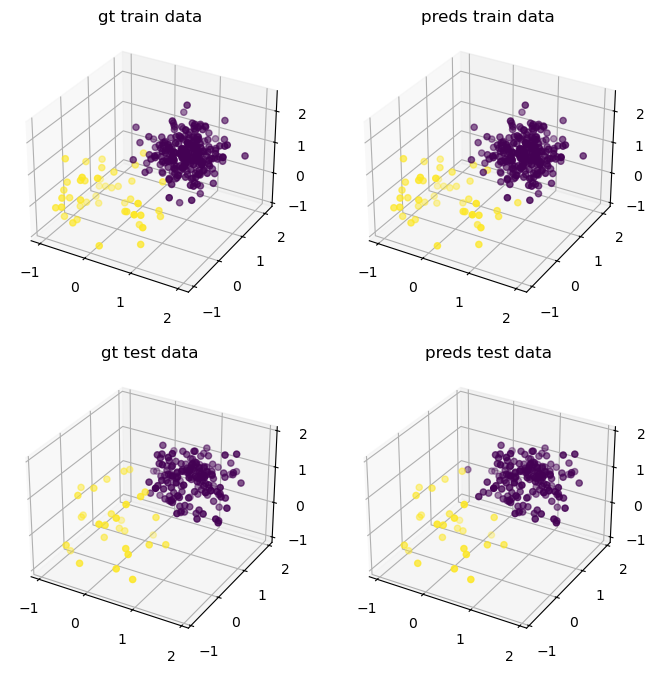

In [9]:

fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap='viridis')
ax.set_title("gt train data")

ax = fig.add_subplot(2, 2, 2, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=train_preds, cmap='viridis')
ax.set_title("preds train data")

ax = fig.add_subplot(2, 2, 3, projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, cmap='viridis')
ax.set_title("gt test data")

ax = fig.add_subplot(2, 2, 4, projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=test_preds, cmap='viridis')
ax.set_title("preds test data")
    
plt.show()


Epoch 1/100, Loss: 9.143549799919128
Epoch 2/100, Loss: 8.829159557819366
Epoch 3/100, Loss: 8.85624635219574
Epoch 4/100, Loss: 8.831998884677887
Epoch 5/100, Loss: 9.20128220319748
Epoch 6/100, Loss: 9.13172471523285
Epoch 7/100, Loss: 8.947853684425354
Epoch 8/100, Loss: 8.791947484016418
Epoch 9/100, Loss: 8.967292249202728
Epoch 10/100, Loss: 9.345803260803223
Epoch 11/100, Loss: 8.678951442241669
Epoch 12/100, Loss: 8.906876802444458
Epoch 13/100, Loss: 8.729129046201706
Epoch 14/100, Loss: 9.861753463745117
Epoch 15/100, Loss: 8.864894270896912
Epoch 16/100, Loss: 8.917382657527924
Epoch 17/100, Loss: 8.816163122653961
Epoch 18/100, Loss: 8.875148355960846
Epoch 19/100, Loss: 8.861423045396805
Epoch 20/100, Loss: 9.34129810333252
Epoch 21/100, Loss: 9.183890640735626
Epoch 22/100, Loss: 9.215877950191498
Epoch 23/100, Loss: 8.89274287223816
Epoch 24/100, Loss: 8.99615478515625
Epoch 25/100, Loss: 8.79707258939743
Epoch 26/100, Loss: 9.20806336402893
Epoch 27/100, Loss: 9.3141919

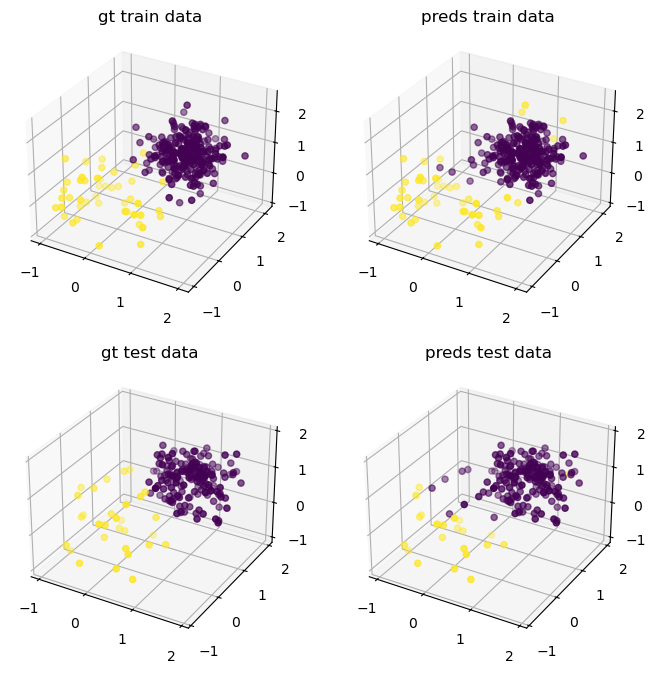

In [10]:
deep_svdd_model = DeepSVDD(n_features=3, contamination=contamination)

deep_svdd_model.fit(X_train)
train_preds = deep_svdd_model.predict(X_train)
test_preds = deep_svdd_model.predict(X_test)

test_balanced_accuracy = balanced_accuracy_score(y_test, test_preds)
test_roc_auc = roc_auc_score(y_test, test_preds) 

print(test_balanced_accuracy)
print(test_roc_auc)


fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap='viridis')
ax.set_title("gt train data")

ax = fig.add_subplot(2, 2, 2, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=train_preds, cmap='viridis')
ax.set_title("preds train data")

ax = fig.add_subplot(2, 2, 3, projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, cmap='viridis')
ax.set_title("gt test data")

ax = fig.add_subplot(2, 2, 4, projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=test_preds, cmap='viridis')
ax.set_title("preds test data")
    
plt.show()

# Ex 2

In [22]:
data = loadmat("cardio 1.mat")
x = data["X"]
y = data["y"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=10)

y_train = [-1 if x == 1 else 1 for x in y_train]
y_test = [-1 if x == 1 else 1 for x in y_test]

one_class_svm = OneClassSVM()
parameters = {'ocsvm__kernel':('linear', 'rbf'), 
              'ocsvm__gamma' :('scale', 'auto'), 
              'ocsvm__nu':[0.3, 0.5, 0.8, sum(y_train) / len(y_train)]}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ocsvm', OneClassSVM())
])

clf = GridSearchCV(estimator=pipeline, 
                   param_grid=parameters, 
                   scoring=make_scorer(balanced_accuracy_score))
clf.fit(x_train, y_train)

best_model = clf.best_estimator_
test_preds = best_model.predict(x_test) 

print(balanced_accuracy_score(test_preds, y_test))
print(clf.best_params_)

0.6498375721667704
{'ocsvm__gamma': 'scale', 'ocsvm__kernel': 'rbf', 'ocsvm__nu': 0.3}


# Ex 3

In [30]:
data = loadmat("shuttle 1.mat")
x = data["X"]
y = data["y"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=10)

std_scaler = StandardScaler()
x_train = std_scaler.fit_transform(x_train)
x_test = std_scaler.transform(x_test)


In [36]:
ocsvm_model = OCSVM()
deepSVDD_model_v1 = DeepSVDD(n_features=9, 
                            hidden_neurons=[32, 16],
                            verbose=0)

deepSVDD_model_v2 = DeepSVDD(n_features=9, 
                            hidden_neurons=[64, 32, 16],
                            verbose=0)

deepSVDD_model_v3 = DeepSVDD(n_features=9, 
                            hidden_neurons=[64, 32], 
                            verbose=0)

print("train ocsvm model")
ocsvm_model.fit(x_train)
print("train deepSVDD_v1 model")
deepSVDD_model_v1.fit(x_train)
print("train deepSVDD_v2 model")
deepSVDD_model_v2.fit(x_train)
print("train deepSVDD_v3 model")
deepSVDD_model_v3.fit(x_train)
print()

print("predict...")
ocsvm_preds = ocsvm_model.predict(x_test)
deepSVDD_v1_preds = deepSVDD_model_v1.predict(x_test)
deepSVDD_v2_preds = deepSVDD_model_v2.predict(x_test)
deepSVDD_v3_preds = deepSVDD_model_v3.predict(x_test)
print("done")

train ocsvm model
train deepSVDD_v1 model
Epoch 1/100, Loss: 349.60581520199776
Epoch 2/100, Loss: 349.6505338847637
Epoch 3/100, Loss: 350.19182536005974
Epoch 4/100, Loss: 349.6364225819707
Epoch 5/100, Loss: 349.6226453334093
Epoch 6/100, Loss: 349.62221010029316
Epoch 7/100, Loss: 349.6385404020548
Epoch 8/100, Loss: 349.63878463953733
Epoch 9/100, Loss: 349.6263348609209
Epoch 10/100, Loss: 349.6929521113634
Epoch 11/100, Loss: 349.6392505019903
Epoch 12/100, Loss: 349.61927549540997
Epoch 13/100, Loss: 349.60741763561964
Epoch 14/100, Loss: 350.1248477101326
Epoch 15/100, Loss: 349.63240391016006
Epoch 16/100, Loss: 349.6253867074847
Epoch 17/100, Loss: 349.6628268957138
Epoch 18/100, Loss: 350.0805426836014
Epoch 19/100, Loss: 349.61476412415504
Epoch 20/100, Loss: 349.6368495002389
Epoch 21/100, Loss: 350.3073387220502
Epoch 22/100, Loss: 349.6193233951926
Epoch 23/100, Loss: 350.0616359040141
Epoch 24/100, Loss: 349.6585378423333
Epoch 25/100, Loss: 350.4362779855728
Epoch 26/

In [37]:
ocsvm_ba = balanced_accuracy_score(y_test, ocsvm_preds)
ocsvm_roc_auc = roc_auc_score(y_test, ocsvm_preds)

deepSVDD_v1_ba = balanced_accuracy_score(y_test, deepSVDD_v1_preds)
deepSVDD_v1_roc_auc = roc_auc_score(y_test, deepSVDD_v1_preds)

deepSVDD_v2_ba = balanced_accuracy_score(y_test, deepSVDD_v2_preds)
deepSVDD_v2_roc_auc = roc_auc_score(y_test, deepSVDD_v2_preds)

deepSVDD_v3_ba = balanced_accuracy_score(y_test, deepSVDD_v3_preds)
deepSVDD_v3_roc_auc = roc_auc_score(y_test, deepSVDD_v3_preds)

print("balanced accs:")
print(f"ocsvm: {ocsvm_ba}")
print(f"deepSVDD_v1: {deepSVDD_v1_ba}")
print(f"deepSVDD_v2: {deepSVDD_v2_ba}")
print(f"deepSVDD_v3: {deepSVDD_v3_ba}")

print()

print("roc auc scores:")
print(f"ocsvm: {ocsvm_roc_auc}")
print(f"deepSVDD_v1: {deepSVDD_v1_roc_auc}")
print(f"deepSVDD_v2: {deepSVDD_v2_roc_auc}")
print(f"deepSVDD_v3: {deepSVDD_v3_roc_auc}")


balanced accs:
ocsvm: 0.9705574043287202
deepSVDD_v1: 0.9656890092762155
deepSVDD_v2: 0.8216511995439881
deepSVDD_v3: 0.9611968520782492

roc auc scores:
ocsvm: 0.9705574043287202
deepSVDD_v1: 0.9656890092762155
deepSVDD_v2: 0.821651199543988
deepSVDD_v3: 0.9611968520782492
